In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

df = pd.read_csv("/Users/thunthita/LidarNRBPipeline/LIDar/csvfiles/20-04-2026/20.30.csv")
AfterPulse = pd.read_csv("/Users/thunthita/LidarNRBPipeline/LIDar/RawFile/AfterPulse.csv")
df

,analog,analog_sterr,photon_counting,pc_sterr,overflow_info
0,5.88390,0.000582,0.000000,0.000000,0.0
1,5.88428,0.000569,0.016681,0.016695,0.0
2,5.88344,0.000569,0.000000,0.000000,0.0
3,5.88427,0.000554,0.000000,0.000000,0.0
4,5.88331,0.000573,0.000000,0.000000,0.0
...,...,...,...,...,...
5019,5.88172,0.000000,0.133445,0.000000,0.0
5020,5.88245,0.000000,0.216847,0.000000,0.0
5021,5.88213,0.000000,0.216847,0.000000,0.0
5022,5.88220,0.000000,0.150125,0.000000,0.0


In [2]:
#parameter

#note: blend region shold be wider than overlap about 50 unit to make a smooth line
config = {
    "bin_width_ns": 25,
    "bin_spacing_m": 3.75,
    "prf_hz": 20,
    "dead_time_ns": 3.06,
    "bg_start_m": 0,
    "bg_end_m": 3750,
    "overlap_r1_m": 2750,
    "overlap_r2_m": 2900,
    "shift_search_bins": 20,
    "afterpulse_provided": True,
    "Sig_start": 3840,
    "Sig_end": 18836.25,
    "k_scale": 0.064021849,
    "b_offset": 0,
}


In [3]:
#parameter

#note: blend region shold be wider than overlap about 50 unit to make a smooth line
config = {
    "bin_width_ns": 25,
    "bin_spacing_m": 3.75,
    "prf_hz": 20,
    "dead_time_ns": 3.06,
    "bg_start_m": 0,
    "bg_end_m": 3750,
    "overlap_r1_m": 2000,
    "overlap_r2_m": 3000,
    "shift_search_bins": 20,
    "afterpulse_provided": True,
    "Sig_start": 3840,
    "Sig_end": 18836.25,
    "k_scale": 0.064021849,
    "b_offset": 0,
}


In [4]:
# add bin no. and bin_spacing 
bin_spacing_m = 3.75
range_m = 2000

# add bin_index (0, 1, 2, ...)
df.insert(0, "bin_index", np.arange(len(df)))

# add range_m (0, 3.75, 7.5, ...)
df.insert(1, "range_m", df["bin_index"] * bin_spacing_m)

#find signal to noise ratio
df["SNR_analog"] = df["analog"] / df["analog_sterr"]
df["SNR_Photon"] = df["photon_counting"] / df["pc_sterr"]

#Change MHz to Photon_per_bin
df["photon_per_bin"] = df["photon_counting"] * config["bin_width_ns"] * 1e-3

print(df.tail())

      bin_index   range_m   analog  analog_sterr  photon_counting  pc_sterr  \
5019       5019  18821.25  5.88172           0.0         0.133445       0.0   
5020       5020  18825.00  5.88245           0.0         0.216847       0.0   
5021       5021  18828.75  5.88213           0.0         0.216847       0.0   
5022       5022  18832.50  5.88220           0.0         0.150125       0.0   
5023       5023  18836.25  5.88196           0.0         0.150125       0.0   

      overflow_info  SNR_analog  SNR_Photon  photon_per_bin  
5019            0.0         inf         inf        0.003336  
5020            0.0         inf         inf        0.005421  
5021            0.0         inf         inf        0.005421  
5022            0.0         inf         inf        0.003753  
5023            0.0         inf         inf        0.003753  


In [5]:
print(df.tail())

      bin_index   range_m   analog  analog_sterr  photon_counting  pc_sterr  \
5019       5019  18821.25  5.88172           0.0         0.133445       0.0   
5020       5020  18825.00  5.88245           0.0         0.216847       0.0   
5021       5021  18828.75  5.88213           0.0         0.216847       0.0   
5022       5022  18832.50  5.88220           0.0         0.150125       0.0   
5023       5023  18836.25  5.88196           0.0         0.150125       0.0   

      overflow_info  SNR_analog  SNR_Photon  photon_per_bin  
5019            0.0         inf         inf        0.003336  
5020            0.0         inf         inf        0.005421  
5021            0.0         inf         inf        0.005421  
5022            0.0         inf         inf        0.003753  
5023            0.0         inf         inf        0.003753  


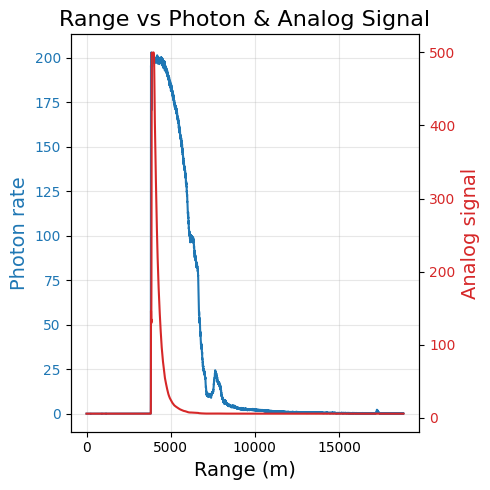

In [6]:
fig, ax1 = plt.subplots(figsize=(5,5))

# Left y-axis (Photon)
ax1.plot(df["range_m"], df["photon_counting"], color="tab:blue", label="Photon rate")
ax1.set_xlabel("Range (m)", fontsize=14)
ax1.set_ylabel("Photon rate", color="tab:blue", fontsize=14)
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.grid(True, alpha=0.3)

# Right y-axis (Analog)
ax2 = ax1.twinx()
ax2.plot(df["range_m"], df["analog"], color="tab:red", label="Analog signal")
ax2.set_ylabel("Analog signal", color="tab:red", fontsize=14)
ax2.tick_params(axis="y", labelcolor="tab:red")

plt.title("Range vs Photon & Analog Signal", fontsize=16)
plt.tight_layout()
plt.show()

In [12]:
df_Sig = df[(df["range_m"] >= config["Sig_start"]) & (df["range_m"] <= config["Sig_end"])]
df_Sig["bin_index"] = df_Sig["bin_index"] - df_Sig["bin_index"].iloc[0]
df_Sig["range_m"] = df_Sig["bin_index"] * bin_spacing_m

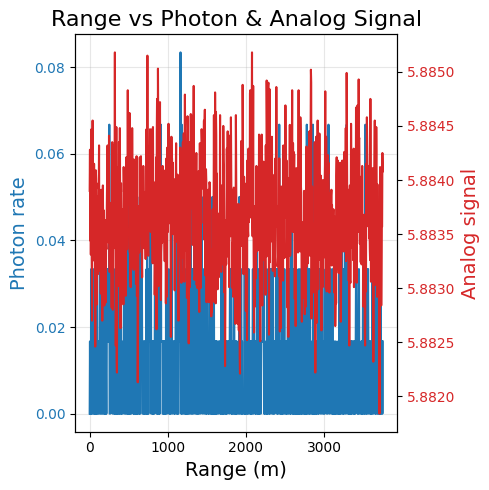

In [15]:
df_Pre = df[(df["range_m"] >= 0) & (df["range_m"] <= 3750)]
fig, ax1 = plt.subplots(figsize=(5,5))

# Left y-axis (Photon)
ax1.plot(df_Pre["range_m"], df_Pre["photon_counting"], color="tab:blue", label="Photon rate")
ax1.set_xlabel("Range (m)", fontsize=14)
ax1.set_ylabel("Photon rate", color="tab:blue", fontsize=14)
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.grid(True, alpha=0.3)

# Right y-axis (Analog)
ax2 = ax1.twinx()
ax2.plot(df_Pre["range_m"], df_Pre["analog"], color="tab:red", label="Analog signal")
ax2.set_ylabel("Analog signal", color="tab:red", fontsize=14)
ax2.tick_params(axis="y", labelcolor="tab:red")

plt.title("Range vs Photon & Analog Signal", fontsize=16)
plt.tight_layout()
plt.show()


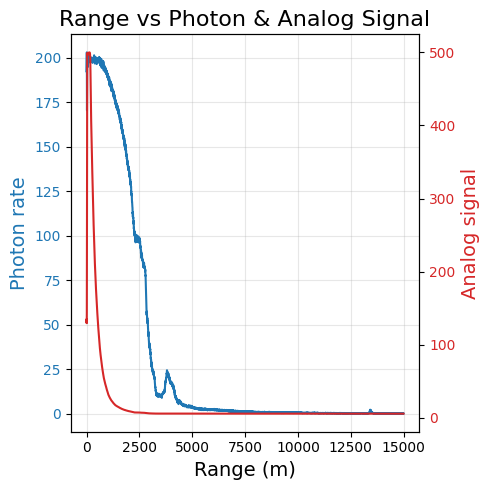

In [17]:
fig, ax1 = plt.subplots(figsize=(5,5))

# Left y-axis (Photon)
ax1.plot(df_Sig["range_m"], df_Sig["photon_counting"], color="tab:blue", label="Photon rate")
ax1.set_xlabel("Range (m)", fontsize=14)
ax1.set_ylabel("Photon rate", color="tab:blue", fontsize=14)
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.grid(True, alpha=0.3)

# Right y-axis (Analog)
ax2 = ax1.twinx()
ax2.plot(df_Sig["range_m"], df_Sig["analog"], color="tab:red", label="Analog signal")
ax2.set_ylabel("Analog signal", color="tab:red", fontsize=14)
ax2.tick_params(axis="y", labelcolor="tab:red")

plt.title("Range vs Photon & Analog Signal", fontsize=16)
plt.tight_layout()
plt.show()


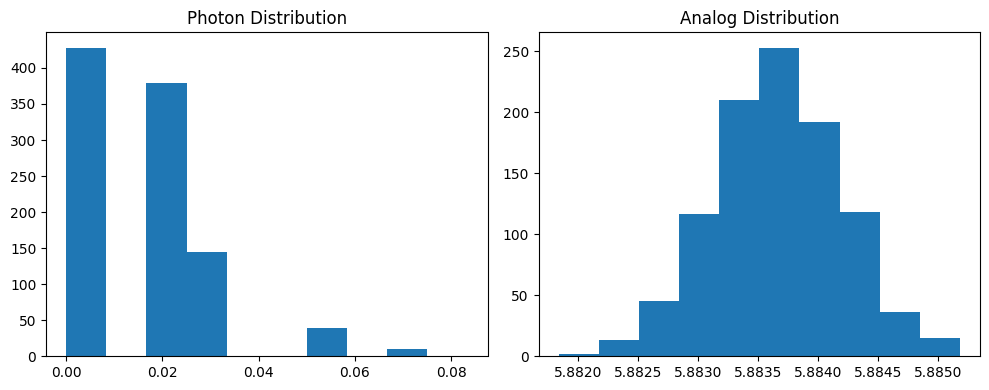

In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,4))

ax1.hist(df_Pre["photon_counting"], bins=10)
ax1.set_title("Photon Distribution")

ax2.hist(df_Pre["analog"], bins=10)
ax2.set_title("Analog Distribution")

plt.tight_layout()
plt.show()

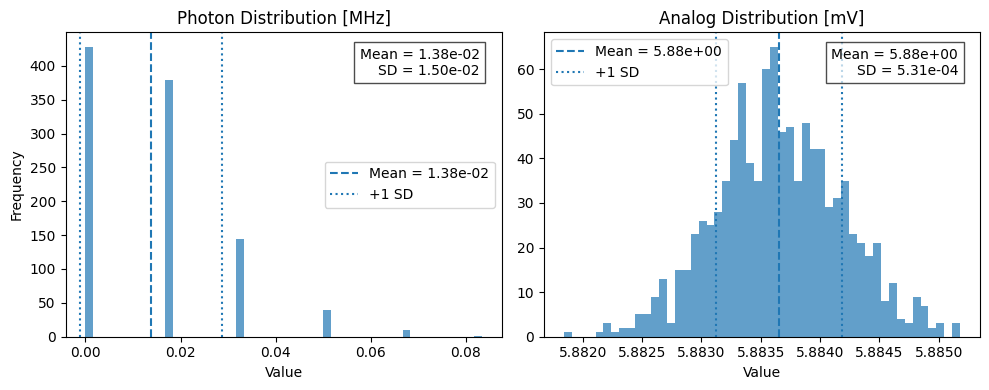

In [21]:
import numpy as np
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,4))

# -------------------------
# Photon
# -------------------------
photon = df_Pre["photon_counting"].dropna()

mu_p = photon.mean()
std_p = photon.std()

ax1.hist(photon, bins=50, alpha=0.7)
ax1.axvline(mu_p, linestyle="--", label=f"Mean = {mu_p:.2e}")
ax1.axvline(mu_p + std_p, linestyle=":", label=f"+1 SD")
ax1.axvline(mu_p - std_p, linestyle=":")

ax1.set_title("Photon Distribution [MHz]")
ax1.set_xlabel("Value")
ax1.set_ylabel("Frequency")

# text box
ax1.text(
    0.95, 0.95,
    f"Mean = {mu_p:.2e}\nSD = {std_p:.2e}",
    transform=ax1.transAxes,
    ha="right",
    va="top",
    bbox=dict(facecolor="white", alpha=0.7)
)

ax1.legend()

# -------------------------
# Analog
# -------------------------
analog = df_Pre["analog"].dropna()

mu_a = analog.mean()
std_a = analog.std()

ax2.hist(analog, bins=50, alpha=0.7)
ax2.axvline(mu_a, linestyle="--", label=f"Mean = {mu_a:.2e}")
ax2.axvline(mu_a + std_a, linestyle=":", label="+1 SD")
ax2.axvline(mu_a - std_a, linestyle=":")

ax2.set_title("Analog Distribution [mV]")
ax2.set_xlabel("Value")

# text box
ax2.text(
    0.95, 0.95,
    f"Mean = {mu_a:.2e}\nSD = {std_a:.2e}",
    transform=ax2.transAxes,
    ha="right",
    va="top",
    bbox=dict(facecolor="white", alpha=0.7)
)

ax2.legend()

plt.tight_layout()
plt.show()

In [22]:
#Find Background for Photon per Bin Rate and Analog Signal
# df_Pre = df[(df["range_m"] >= 0) & (df["range_m"] <= 3750)]
bg_row = df[(df["range_m"] >= config["bg_start_m"]) & (df["range_m"] <= config["bg_end_m"])]

Analog_bg_mean = bg_row["analog"].mean()
Photon_bg_mean = bg_row["photon_per_bin"].mean()

#Show Background value
print("Analog background (mean):", Analog_bg_mean)
print("Photon Per Bin background (mean):", Photon_bg_mean)

Analog background (mean): 5.883654425574425
Photon Per Bin background (mean): 0.0003453595879120879


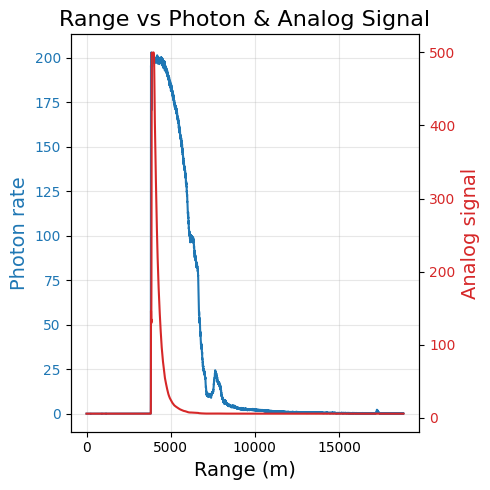

In [25]:
fig, ax1 = plt.subplots(figsize=(5,5))

# Left y-axis (Photon)
ax1.plot(df["range_m"], df["photon_counting"], color="tab:blue", label="Photon rate")
ax1.set_xlabel("Range (m)", fontsize=14)
ax1.set_ylabel("Photon rate", color="tab:blue", fontsize=14)
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.grid(True, alpha=0.3)

# Right y-axis (Analog)
ax2 = ax1.twinx()
ax2.plot(df["range_m"], df["analog"], color="tab:red", label="Analog signal")
ax2.set_ylabel("Analog signal", color="tab:red", fontsize=14)
ax2.tick_params(axis="y", labelcolor="tab:red")

plt.title("Range vs Photon & Analog Signal", fontsize=16)
plt.tight_layout()
plt.show()

In [27]:
df_Sig

,bin_index,range_m,analog,analog_sterr,photon_counting,pc_sterr,overflow_info,SNR_analog,SNR_Photon,photon_per_bin
1024,0,0.00,131.00800,0.183648,192.344000,0.870157,0.0,713.364698,221.045168,4.808600
1025,1,3.75,135.27300,0.202470,193.611000,0.895029,1.0,668.113795,216.318130,4.840275
1026,2,7.50,129.84500,0.168341,197.281000,0.878675,0.0,771.321306,224.521012,4.932025
1027,3,11.25,129.66400,0.151196,199.416000,0.886170,1.0,857.588825,225.031315,4.985400
1028,4,15.00,144.84000,0.239346,202.952000,0.890940,0.0,605.149031,227.795362,5.073800
...,...,...,...,...,...,...,...,...,...,...
5019,3995,14981.25,5.88172,0.000000,0.133445,0.000000,0.0,inf,inf,0.003336
5020,3996,14985.00,5.88245,0.000000,0.216847,0.000000,0.0,inf,inf,0.005421
5021,3997,14988.75,5.88213,0.000000,0.216847,0.000000,0.0,inf,inf,0.005421
5022,3998,14992.50,5.88220,0.000000,0.150125,0.000000,0.0,inf,inf,0.003753


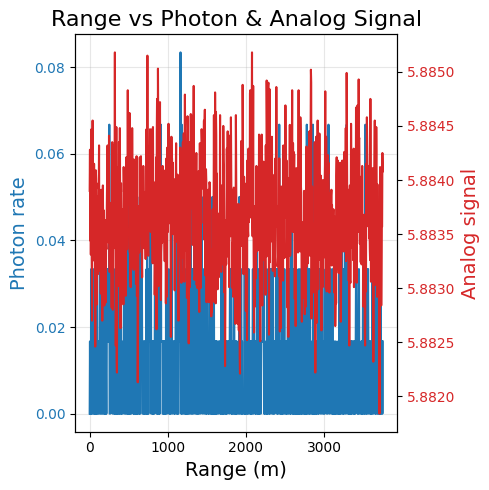

In [29]:
fig, ax1 = plt.subplots(figsize=(5,5))

# Left y-axis (Photon)
ax1.plot(bg_row["range_m"], bg_row["photon_counting"], color="tab:blue", label="Photon rate")
ax1.set_xlabel("Range (m)", fontsize=14)
ax1.set_ylabel("Photon rate", color="tab:blue", fontsize=14)
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.grid(True, alpha=0.3)

# Right y-axis (Analog)
ax2 = ax1.twinx()
ax2.plot(bg_row["range_m"], bg_row["analog"], color="tab:red", label="Analog signal")
ax2.set_ylabel("Analog signal", color="tab:red", fontsize=14)
ax2.tick_params(axis="y", labelcolor="tab:red")

plt.title("Range vs Photon & Analog Signal", fontsize=16)
plt.tight_layout()
plt.show()

In [31]:
df_Sig = df_Sig.copy()
df_Sig["analog_bg_corr"] = df_Sig["analog"] - Analog_bg_mean
df_Sig["Photon_per_bin_bg_corr"] = df_Sig["photon_per_bin"] - Photon_bg_mean

df_Sig["afterpulse_raw"] = AfterPulse["afterpulse_raw"]
df_Sig["afterpulse_counts_per_bin"] = (
    df_Sig["afterpulse_raw"] * config["bin_width_ns"] * 1e-3
)

df_Sig["photon_APcorr_counts"] = (
    df_Sig["Photon_per_bin_bg_corr"] - df_Sig["afterpulse_counts_per_bin"]
)

bin_width_s = config["bin_width_ns"] * 1e-9
dead_time_s = config["dead_time_ns"] * 1e-9

df_Sig["photon_deadtime_counts"] = (
    df_Sig["photon_APcorr_counts"]
    / (1 - df_Sig["photon_APcorr_counts"] * dead_time_s / bin_width_s)
)

# It will be invalid in this case
ratio = df_Sig["photon_deadtime_counts"] * dead_time_s / bin_width_s

df_Sig["photon_deadtime_corr"] = np.where(
    ratio < 1,
    df_Sig["photon_deadtime_counts"] / (1 - ratio),
    np.nan  # invalid / saturated
)

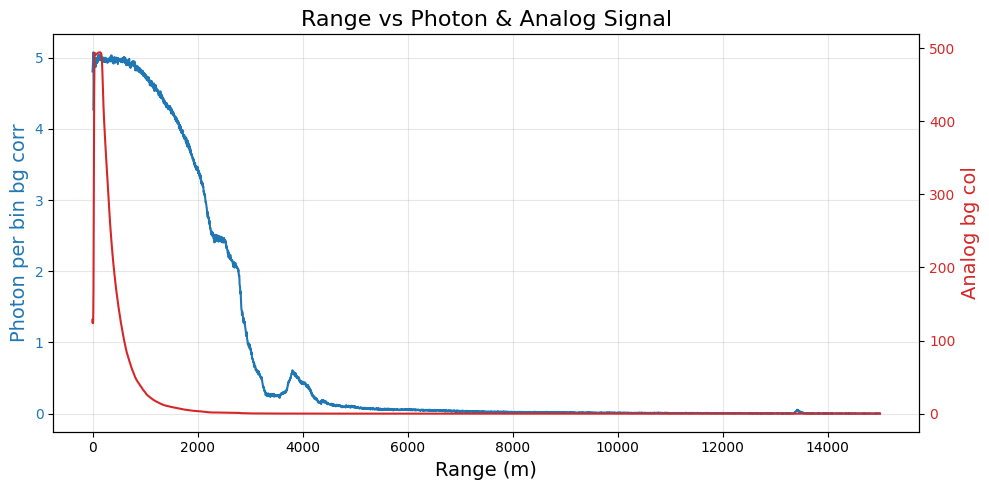

In [33]:
fig, ax1 = plt.subplots(figsize=(10,5))

# Left y-axis (Photon)
ax1.plot(df_Sig["range_m"], df_Sig["Photon_per_bin_bg_corr"], color="tab:blue", label="Photon rate")
ax1.set_xlabel("Range (m)", fontsize=14)
ax1.set_ylabel("Photon per bin bg corr", color="tab:blue", fontsize=14)
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.grid(True, alpha=0.3)

# Right y-axis (Analog)
ax2 = ax1.twinx()
ax2.plot(df_Sig["range_m"], df_Sig["analog_bg_corr"], color="tab:red", label="Analog signal")
ax2.set_ylabel("Analog bg col", color="tab:red", fontsize=14)
ax2.tick_params(axis="y", labelcolor="tab:red")


plt.title("Range vs Photon & Analog Signal", fontsize=16)
plt.tight_layout()
plt.show()


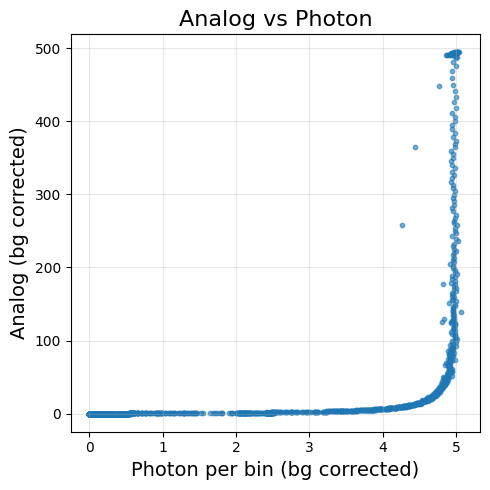

In [35]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5,5))

ax.scatter(
    df_Sig["Photon_per_bin_bg_corr"],
    df_Sig["analog_bg_corr"],
    s=10,
    alpha=0.6
)

ax.set_xlabel("Photon per bin (bg corrected)", fontsize=14)
ax.set_ylabel("Analog (bg corrected)", fontsize=14)
ax.set_title("Analog vs Photon", fontsize=16)

ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

k_scale = 0.8132885541633763 b_offset = 1.0440485142451792 R^2 = 0.9105967478437238


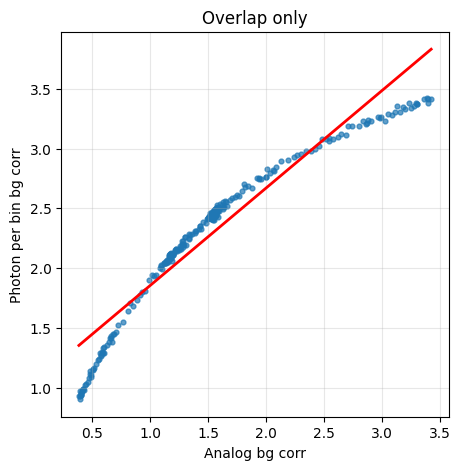

In [37]:
# --- overlap region from df_Sig ---
m_overlap = df_Sig[
    (df_Sig["range_m"] >= config["overlap_r1_m"]) &
    (df_Sig["range_m"] <= config["overlap_r2_m"])
]

x = m_overlap["analog_bg_corr"].to_numpy()
y = m_overlap["Photon_per_bin_bg_corr"].to_numpy()

k_scale, b_offset, r, *_ = linregress(x, y)

print("k_scale =", k_scale,
      "b_offset =", b_offset,
      "R^2 =", r**2)

#visualized
fig, ax = plt.subplots(figsize=(5,5))
ax.scatter(m_overlap["analog_bg_corr"], m_overlap["Photon_per_bin_bg_corr"], s=12, alpha=0.7)

xfit = np.linspace(m_overlap["analog_bg_corr"].min(), m_overlap["analog_bg_corr"].max(), 100)
yfit = k_scale * xfit + b_offset
ax.plot(xfit, yfit, color="red", lw=2)

ax.set_xlabel("Analog bg corr")
ax.set_ylabel("Photon per bin bg corr")
ax.set_title("Overlap only")
ax.grid(True, alpha=0.3)
plt.show()

# --- scale analog ---
df_Sig["analog_scaled_for_glue"] = (
    k_scale * df_Sig["analog_bg_corr"] + b_offset
)

# --- blend region ---
blend_r1_m = config["overlap_r1_m"] - 100
blend_r2_m = config["overlap_r2_m"] + 100

r = df_Sig["range_m"].to_numpy()

w = np.zeros_like(r, dtype=float)

# r > r2 → photon dominates
w[r > blend_r2_m] = 1.0

# cosine blend
m = (r >= blend_r1_m) & (r <= blend_r2_m)
w[m] = 0.5 * (
    1.0 - np.cos(np.pi * (r[m] - blend_r1_m) / (blend_r2_m - blend_r1_m))
)

df_Sig["weight_w"] = w

# --- merge ---
df_Sig["merged_counts_per_bin"] = (
    (1.0 - df_Sig["weight_w"]) * df_Sig["analog_scaled_for_glue"]
    + df_Sig["weight_w"] * df_Sig["Photon_per_bin_bg_corr"]
)

# --- range² correction ---
df_Sig["range2_corrected_counts"] = (
    df_Sig["merged_counts_per_bin"] * df_Sig["range_m"]**2
)

# --- normalization ---
df_Sig["range2_norm"] = (
    df_Sig["range2_corrected_counts"] /
    df_Sig["range2_corrected_counts"].max()
)

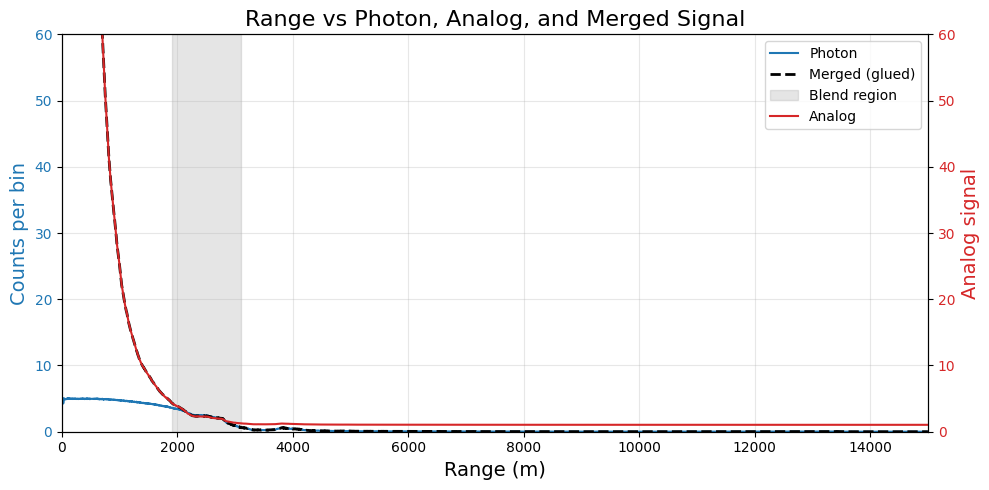

In [39]:
fig, ax1 = plt.subplots(figsize=(10,5))

# --- Left y-axis: Photon + Merged ---
ax1.plot(
    df_Sig["range_m"],
    df_Sig["Photon_per_bin_bg_corr"],
    color="tab:blue",
    label="Photon"
)

ax1.plot(
    df_Sig["range_m"],
    df_Sig["merged_counts_per_bin"],
    color="black",
    linestyle="--",
    linewidth=2,
    label="Merged (glued)"
)

ax1.set_xlabel("Range (m)", fontsize=14)
ax1.set_ylabel("Counts per bin", color="tab:blue", fontsize=14)
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.grid(True, alpha=0.3)

# --- Blend region ---
ax1.axvspan(
    blend_r1_m,
    blend_r2_m,
    color="gray",
    alpha=0.2,
    label="Blend region"
)

ax1.set_xlim(0, 15000)
ax1.set_ylim(0, 60)
# --- Right y-axis: Analog ---
ax2 = ax1.twinx()
ax2.plot(
    df_Sig["range_m"],
    df_Sig["analog_scaled_for_glue"],
    color="tab:red",
    label="Analog"
)

ax2.set_ylabel("Analog signal", color="tab:red", fontsize=14)
ax2.tick_params(axis="y", labelcolor="tab:red")
ax2.set_ylim(0, 60)

# --- Legend (combine both axes) ---
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="best")

plt.title("Range vs Photon, Analog, and Merged Signal", fontsize=16)
plt.tight_layout()
plt.show()

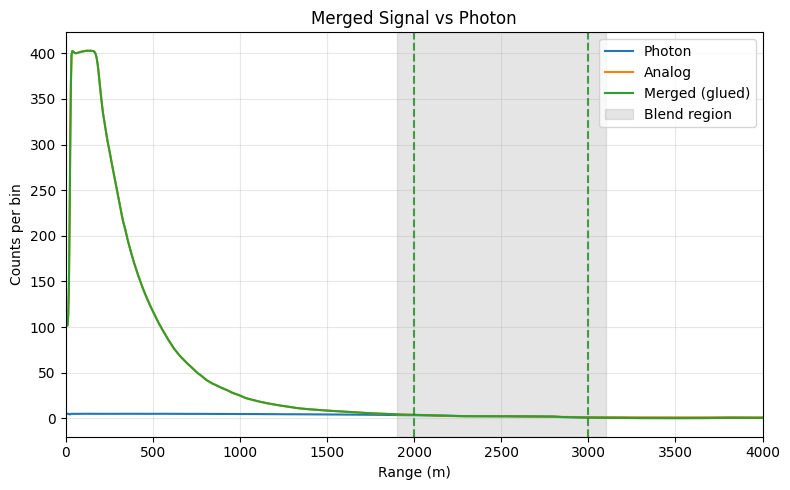

In [41]:
def plot_vs_range(
    df,
    ycols,
    *,
    xcol="range_m",
    labels=None,
    title=None,
    xlabel="Range (m)",
    ylabel=None,
    yscale="linear",
    xlim=None,
    ylim=None,
    figsize=(8,5),
    blend_region=None,      # (r1, r2)
    overlap_region=None,    # (r1, r2)
):
    plt.figure(figsize=figsize)

    if labels is None:
        labels = ycols

    for y, lab in zip(ycols, labels):
        plt.plot(df[xcol], df[y], label=lab)

    # --- Blend region ---
    if blend_region:
        plt.axvspan(
            blend_region[0],
            blend_region[1],
            color="gray",
            alpha=0.2,
            label="Blend region"
        )

    # --- Overlap region ---
    if overlap_region:
        plt.axvline(overlap_region[0], color="green", linestyle="--", alpha=0.7)
        plt.axvline(overlap_region[1], color="green", linestyle="--", alpha=0.7)

    plt.xlabel(xlabel)
    if ylabel:
        plt.ylabel(ylabel)
    if title:
        plt.title(title)

    plt.yscale(yscale)

    if xlim:
        plt.xlim(*xlim)
    if ylim:
        plt.ylim(*ylim)

    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_vs_range(
    df_Sig,
    ycols=[
        "Photon_per_bin_bg_corr",
        "analog_scaled_for_glue",
        "merged_counts_per_bin",
    ],
    labels=[
        "Photon",
        "Analog",
        "Merged (glued)",
    ],
    ylabel="Counts per bin",
    yscale="linear",
    xlim=(0, 4000),
    title="Merged Signal vs Photon",
    blend_region=(blend_r1_m, blend_r2_m),
    overlap_region=(config["overlap_r1_m"], config["overlap_r2_m"]),
)

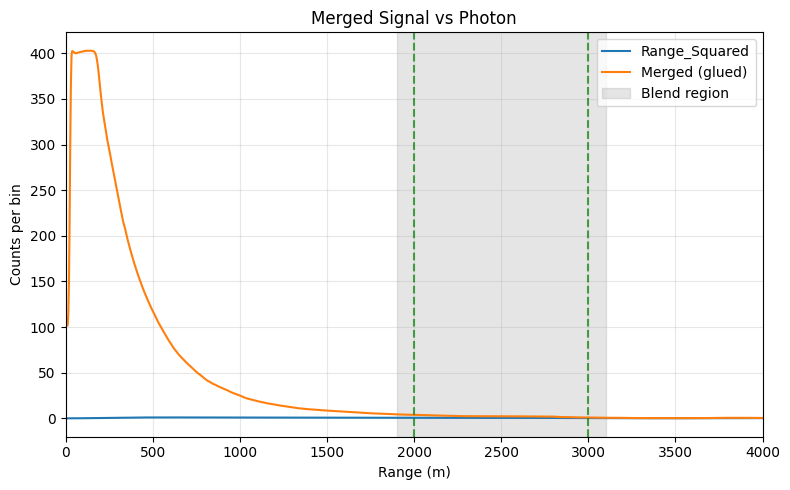

In [43]:
plot_vs_range(
    df_Sig,
    ycols=[
        "range2_norm",
        "merged_counts_per_bin",
    ],
    labels=[
        "Range_Squared",
        "Merged (glued)",
    ],
    ylabel="Counts per bin",
    yscale="linear",
    xlim=(0, 4000),
    title="Merged Signal vs Photon",
    blend_region=(blend_r1_m, blend_r2_m),
    overlap_region=(config["overlap_r1_m"], config["overlap_r2_m"]),
)

In [45]:
df_Sig

,bin_index,range_m,analog,analog_sterr,photon_counting,pc_sterr,overflow_info,SNR_analog,SNR_Photon,photon_per_bin,...,afterpulse_raw,afterpulse_counts_per_bin,photon_APcorr_counts,photon_deadtime_counts,photon_deadtime_corr,analog_scaled_for_glue,weight_w,merged_counts_per_bin,range2_corrected_counts,range2_norm
1024,0,0.00,131.00800,0.183648,192.344000,0.870157,0.0,713.364698,221.045168,4.808600,...,0.0,0.0,4.808255,11.685564,NaN,102.806247,0.0,102.806247,0.000000e+00,0.000000
1025,1,3.75,135.27300,0.202470,193.611000,0.895029,1.0,668.113795,216.318130,4.840275,...,0.0,0.0,4.839930,11.874429,NaN,106.274922,0.0,106.274922,1.494491e+03,0.000050
1026,2,7.50,129.84500,0.168341,197.281000,0.878675,0.0,771.321306,224.521012,4.932025,...,0.0,0.0,4.931680,12.442349,NaN,101.860392,0.0,101.860392,5.729647e+03,0.000191
1027,3,11.25,129.66400,0.151196,199.416000,0.886170,1.0,857.588825,225.031315,4.985400,...,0.0,0.0,4.985055,12.787788,NaN,101.713187,0.0,101.713187,1.287308e+04,0.000429
1028,4,15.00,144.84000,0.239346,202.952000,0.890940,0.0,605.149031,227.795362,5.073800,...,0.0,0.0,5.073455,13.386101,NaN,114.055654,0.0,114.055654,2.566252e+04,0.000855
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5019,3995,14981.25,5.88172,0.000000,0.133445,0.000000,0.0,inf,inf,0.003336,...,NaN,NaN,NaN,NaN,NaN,1.042475,1.0,0.002991,6.712410e+05,0.022356
5020,3996,14985.00,5.88245,0.000000,0.216847,0.000000,0.0,inf,inf,0.005421,...,NaN,NaN,NaN,NaN,NaN,1.043069,1.0,0.005076,1.139775e+06,0.037960
5021,3997,14988.75,5.88213,0.000000,0.216847,0.000000,0.0,inf,inf,0.005421,...,NaN,NaN,NaN,NaN,NaN,1.042809,1.0,0.005076,1.140346e+06,0.037979
5022,3998,14992.50,5.88220,0.000000,0.150125,0.000000,0.0,inf,inf,0.003753,...,NaN,NaN,NaN,NaN,NaN,1.042866,1.0,0.003408,7.659807e+05,0.025511


In [47]:
m_overlap = (
    (df_Sig["range_m"] >= config["overlap_r1_m"]) &
    (df_Sig["range_m"] <= config["overlap_r2_m"])
)

ratio = (
    df_Sig.loc[m_overlap, "analog_scaled_for_glue"] /
    df_Sig.loc[m_overlap, "photon_APcorr_counts"]
)

#On average, the scaled analog signal is (ratio mean - 1) * 100 % higher than the photon signal in the overlap region.
print("ratio mean:", ratio.mean())
#How much the ratio fluctuates from bin to bin around the mean.
print("ratio std :", ratio.std())

ratio mean: nan
ratio std : nan


In [49]:
df

,bin_index,range_m,analog,analog_sterr,photon_counting,pc_sterr,overflow_info,SNR_analog,SNR_Photon,photon_per_bin
0,0,0.00,5.88390,0.000582,0.000000,0.000000,0.0,1.010308e+04,NaN,0.000000
1,1,3.75,5.88428,0.000569,0.016681,0.016695,0.0,1.033436e+04,0.999167,0.000417
2,2,7.50,5.88344,0.000569,0.000000,0.000000,0.0,1.033878e+04,NaN,0.000000
3,3,11.25,5.88427,0.000554,0.000000,0.000000,0.0,1.062912e+04,NaN,0.000000
4,4,15.00,5.88331,0.000573,0.000000,0.000000,0.0,1.026471e+04,NaN,0.000000
...,...,...,...,...,...,...,...,...,...,...
5019,5019,18821.25,5.88172,0.000000,0.133445,0.000000,0.0,inf,inf,0.003336
5020,5020,18825.00,5.88245,0.000000,0.216847,0.000000,0.0,inf,inf,0.005421
5021,5021,18828.75,5.88213,0.000000,0.216847,0.000000,0.0,inf,inf,0.005421
5022,5022,18832.50,5.88220,0.000000,0.150125,0.000000,0.0,inf,inf,0.003753


In [51]:
#MiniMPL
MiniMPL = pd.read_csv("/Users/thunthita/LidarNRBPipeline/LIDar/RawFile/20-04-2026-DATfile/MPL_5038_202604202030.csv")
MiniMPL["range_raw"]

0       0.029979
1       0.059958
2       0.089938
3       0.119917
4       0.149896
         ...    
995    29.859330
996    29.889309
997    29.919287
998    29.949266
999    29.979246
Name: range_raw, Length: 1000, dtype: float64

In [53]:
# Select + rename columns
MiniMPL_for_process = pd.DataFrame({
    "range_raw": MiniMPL["range_raw"],
    "range (m) for NRB": MiniMPL["range_raw"]*1000,
    "range (m)": MiniMPL["range_nrb"]*1000,
    "copol_raw": MiniMPL["copol_raw"],
    "copol_snr": MiniMPL["copol_snr"],
    "copol_nrb": MiniMPL["copol_nrb"],
    "pbls": MiniMPL["pbls"],
    "Normalize_copol_nrb": MiniMPL["copol_nrb"]/MiniMPL["copol_nrb"].max(),
})

# Save to CSV
MiniMPL_for_process.to_csv("MiniMPL_for_process_202604202030.csv", index=False)

In [55]:
MiniMPL_for_process = pd.read_csv("MiniMPL_for_process_202604202030.csv")
MiniMPL_for_process

,range_raw,range (m) for NRB,range (m),copol_raw,copol_snr,copol_nrb,pbls,Normalize_copol_nrb
0,0.029979,29.979246,119.91698,27.147165,91792.836000,0.501752,1.349066,0.963413
1,0.059958,59.958490,149.89623,17.552433,59347.367000,0.496653,NaN,0.953624
2,0.089938,89.937740,179.87548,17.204344,58193.617000,0.483747,NaN,0.928842
3,0.119917,119.916980,209.85472,17.288532,58427.367000,0.466687,NaN,0.896084
4,0.149896,149.896230,239.83397,16.461535,55637.970000,0.460777,NaN,0.884737
...,...,...,...,...,...,...,...,...
995,29.859330,29859.330000,NaN,0.000803,0.231162,NaN,NaN,NaN
996,29.889309,29889.309000,NaN,0.000699,-0.092135,NaN,NaN,NaN
997,29.919287,29919.287000,NaN,0.000714,-0.061050,NaN,NaN,NaN
998,29.949266,29949.266000,NaN,0.000625,-0.364440,NaN,NaN,NaN


In [57]:
# plot_xy(
#     MiniMPL_for_process,
#     xcol="range_raw",
#     ycol="copol_raw",
#     yscale="linear",
#     title="Range Raw vs Copol Raw (MiniMPL)",
#     xlabel="Range Raw (m)",
#     ylabel="Copol Raw",
#     outfile="RawFilePicforExample/MiniMPL/Range_Raw_vs_Copol_Raw(MiniMPL).png",
# )

In [59]:
# plot_xy(
#     MiniMPL_for_process,
#     xcol="range_raw",
#     ycol="copol_snr",
#     yscale="linear",
#     title="Range Raw vs Copol SNR (MiniMPL)",
#     xlabel="Range Raw (m)",
#     ylabel="Copol SNR",
#     outfile="RawFilePicforExample/MiniMPL/Range_Raw_vs_Copol_SNR(MiniMPL).png",
# )

In [61]:
# plot_xy(
#     MiniMPL_for_process,
#     xcol="range_raw",
#     ycol="copol_nrb",
#     yscale="linear",
#     title="Range Raw vs Copol NRB (MiniMPL)",
#     xlabel="Range Raw (m)",
#     ylabel="Copol NRB",
#     outfile="RawFilePicforExample/MiniMPL/Range_Raw_vs_Copol_NRB(MiniMPL).png",
# )

In [63]:
# plot_xy(
#     MiniMPL_for_process,
#     xcol="range_raw",
#     ycol="Normalize copol nrb",
#     yscale="linear",
#     title="Range Raw vs Normalize Copol NRB (MiniMPL)",
#     xlabel="Range Raw (m)",
#     ylabel="Normalize Copol NRB",
#     outfile="RawFilePicforExample/MiniMPL/Range_Raw_vs_Normalize_copol_nrb(MiniMPL).png",
# )

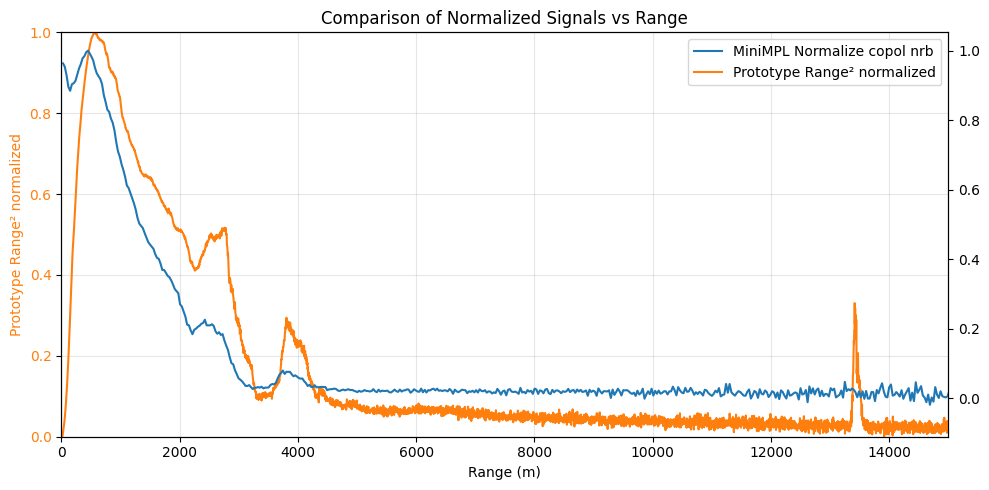

In [65]:
fig, ax1 = plt.subplots(figsize=(10,5))

# ---- Left axis (Prototype) ----
color1 = "tab:orange"

ax1.plot(
    df_Sig["range_m"],
    df_Sig["range2_norm"],
    label="Prototype Range² normalized",
    color=color1,
)

ax1.set_xlabel("Range (m)")
ax1.set_ylabel("Prototype Range² normalized", color=color1)
ax1.tick_params(axis="y", labelcolor=color1)
ax1.set_xlim(0,15000)
ax1.set_ylim(0,1)

# ---- Right axis (MiniMPL) ----
ax2 = ax1.twinx()

color2 = "tab:blue"

ax2.plot(
    MiniMPL_for_process["range (m) for NRB"],
    MiniMPL_for_process["Normalize_copol_nrb"],
    label="MiniMPL Normalize copol nrb",
    color=color2,
)

# ax2.set_ylabel("MiniMPL Normalized NRB", color=color2)
# ax2.tick_params(axis="y", labelcolor=color2)
# ax2.set_ylim(0,1)
# ---- Title / grid ----
ax1.set_title("Comparison of Normalized Signals vs Range")
ax1.grid(True, alpha=0.3)

# ---- Combined legend (MiniMPL first) ----
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(lines2 + lines1, labels2 + labels1)

plt.tight_layout()
plt.show()

In [37]:
import numpy as np
import pandas as pd
from scipy.stats import linregress

def auto_detect_overlap_region(
    df,
    analog_col="analog_bg_corr",
    photon_col="Photon_per_bin_bg_corr",
    range_col="range_m",
    r_min=100,
    r_max=3000,
    window_m=150,
    step_m=25,
    min_points=20,
    r2_min=0.95,
):
    results = []

    for start in np.arange(r_min, r_max - window_m + step_m, step_m):
        end = start + window_m

        d = df[
            (df[range_col] >= start) &
            (df[range_col] <= end)
        ][[range_col, analog_col, photon_col]].copy()

        # clean
        d = d.replace([np.inf, -np.inf], np.nan).dropna()
        d = d[(d[analog_col] > 0) & (d[photon_col] > 0)]

        if len(d) < min_points:
            continue

        x = d[analog_col].to_numpy()
        y = d[photon_col].to_numpy()

        slope, intercept, r, p, stderr = linregress(x, y)
        r2 = r**2

        # optional extra metric: relative residual
        y_fit = slope * x + intercept
        rmse = np.sqrt(np.mean((y - y_fit)**2))
        rel_rmse = rmse / np.mean(y)

        results.append({
            "start_m": start,
            "end_m": end,
            "n_points": len(d),
            "slope": slope,
            "intercept": intercept,
            "r2": r2,
            "rel_rmse": rel_rmse,
        })

    results_df = pd.DataFrame(results)

    if results_df.empty:
        return None, None

    # keep only physically reasonable windows
    candidates = results_df[
        (results_df["slope"] > 0) &
        (results_df["r2"] >= r2_min)
    ].copy()

    if candidates.empty:
        # fallback: choose highest R²
        best = results_df.sort_values(
            by=["r2", "rel_rmse"],
            ascending=[False, True]
        ).iloc[0]
    else:
        # choose best by high R² + low residual
        best = candidates.sort_values(
            by=["r2", "rel_rmse"],
            ascending=[False, True]
        ).iloc[0]

    return best, results_df


best, scan_table = auto_detect_overlap_region(
    df_Sig,
    r_min=100,
    r_max=3000,
    window_m=150,
    step_m=25,
    min_points=20,
    r2_min=0.95,
)

print(best)

start_m      2750.000000
end_m        2900.000000
n_points       40.000000
slope           1.390149
intercept       0.496607
r2              0.993949
rel_rmse        0.013656
Name: 106, dtype: float64


In [69]:
#MiniMPL
NRB_processed = pd.read_csv("/Users/thunthita/LidarNRBPipeline/LIDar/ExampleCode/Pipeline_Test/lidar_output.csv")
NRB_processed

,bin_index,range_m,analog,analog_sterr,photon_counting,pc_sterr,overflow_info,photon_counting_shifted,photon_deadtime_corr,analog_scaled_for_glue,weight_w,merged_sig,merged_sig_bg_corr,range2_corrected_counts,nrb,range2_norm
0,0,0.00,131.00800,0.183648,192.344000,0.870157,0.0,192.344000,467.504154,13445.719455,0.0,13445.719455,13445.705639,0.000000e+00,0.000000e+00,0.000000
1,1,3.75,135.27300,0.202470,193.611000,0.895029,1.0,193.611000,475.060332,13904.021989,0.0,13904.021989,13904.008174,1.955251e+05,7.821005e+06,0.000050
2,2,7.50,129.84500,0.168341,197.281000,0.878675,0.0,197.281000,497.781919,13320.747392,0.0,13320.747392,13320.733576,7.492913e+05,2.997165e+07,0.000191
3,3,11.25,129.66400,0.151196,199.416000,0.886170,1.0,199.416000,511.602438,13301.297742,0.0,13301.297742,13301.283926,1.683444e+06,6.733775e+07,0.000429
4,4,15.00,144.84000,0.239346,202.952000,0.890940,0.0,202.952000,535.540203,14932.059586,0.0,14932.059586,14932.045770,3.359710e+06,1.343884e+08,0.000856
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,3995,14981.25,5.88172,0.000000,0.133445,0.000000,0.0,0.133445,0.133500,0.070855,1.0,0.133500,0.119684,2.686159e+07,1.074464e+09,0.006846
3996,3996,14985.00,5.88245,0.000000,0.216847,0.000000,0.0,0.216847,0.216991,0.149298,1.0,0.216991,0.203175,4.562307e+07,1.824923e+09,0.011628
3997,3997,14988.75,5.88213,0.000000,0.216847,0.000000,0.0,0.216847,0.216991,0.114912,1.0,0.216991,0.203175,4.564590e+07,1.825836e+09,0.011634
3998,3998,14992.50,5.88220,0.000000,0.150125,0.000000,0.0,0.150125,0.150194,0.122434,1.0,0.150194,0.136378,3.065445e+07,1.226178e+09,0.007813


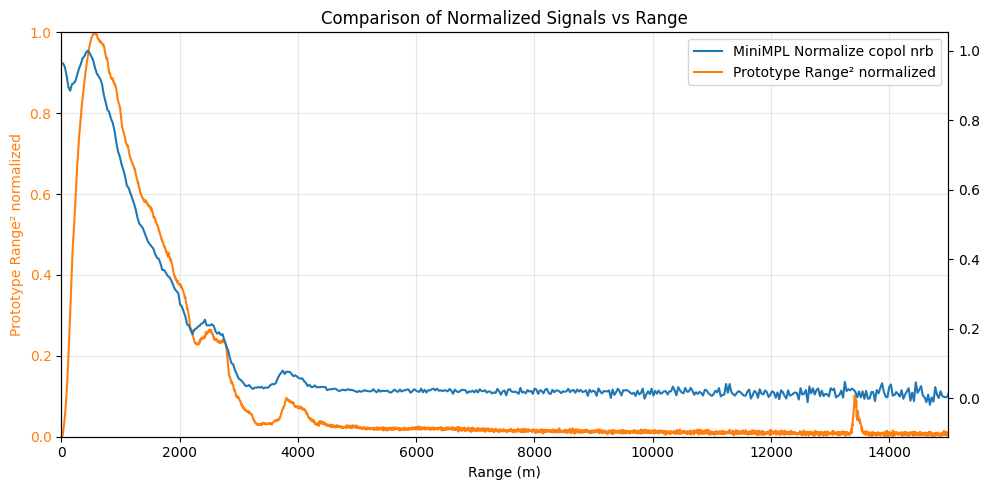

In [71]:
fig, ax1 = plt.subplots(figsize=(10,5))

# ---- Left axis (Prototype) ----
color1 = "tab:orange"

ax1.plot(
    NRB_processed["range_m"],
    NRB_processed["range2_norm"],
    label="Prototype Range² normalized",
    color=color1,
)

ax1.set_xlabel("Range (m)")
ax1.set_ylabel("Prototype Range² normalized", color=color1)
ax1.tick_params(axis="y", labelcolor=color1)
ax1.set_xlim(0,15000)
ax1.set_ylim(0,1)

# ---- Right axis (MiniMPL) ----
ax2 = ax1.twinx()

color2 = "tab:blue"

ax2.plot(
    MiniMPL_for_process["range (m) for NRB"],
    MiniMPL_for_process["Normalize_copol_nrb"],
    label="MiniMPL Normalize copol nrb",
    color=color2,
)

# ax2.set_ylabel("MiniMPL Normalized NRB", color=color2)
# ax2.tick_params(axis="y", labelcolor=color2)
# ax2.set_ylim(0,1)
# ---- Title / grid ----
ax1.set_title("Comparison of Normalized Signals vs Range")
ax1.grid(True, alpha=0.3)

# ---- Combined legend (MiniMPL first) ----
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(lines2 + lines1, labels2 + labels1)

plt.tight_layout()
plt.show()

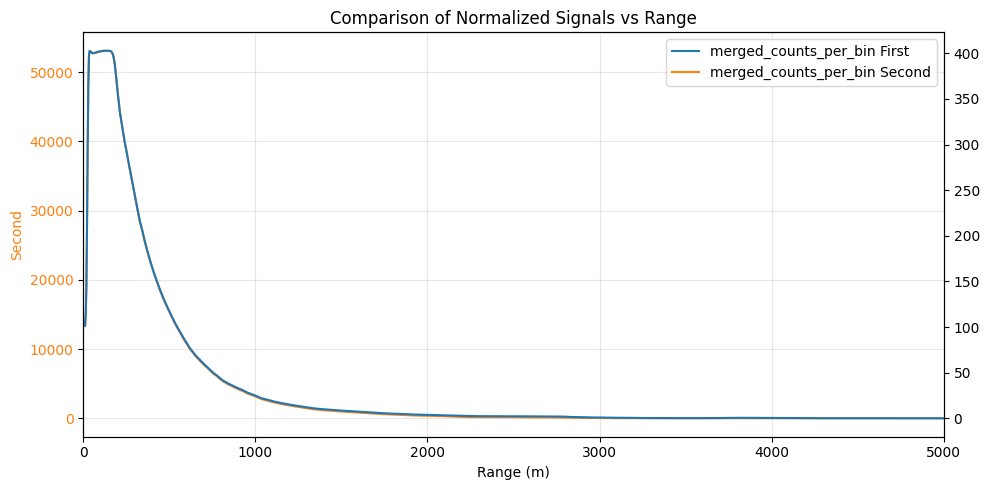

In [73]:
fig, ax1 = plt.subplots(figsize=(10,5))

# ---- Left axis (Prototype) ----
color1 = "tab:orange"

ax1.plot(
    NRB_processed["range_m"],
    NRB_processed["merged_sig_bg_corr"],
    label="merged_counts_per_bin Second",
    color=color1,
)

ax1.set_xlabel("Range (m)")
ax1.set_ylabel("Second", color=color1)
ax1.tick_params(axis="y", labelcolor=color1)
ax1.set_xlim(0,5000)


# ---- Right axis (MiniMPL) ----
ax2 = ax1.twinx()

color2 = "tab:blue"

ax2.plot(
    df_Sig["range_m"],
    df_Sig["merged_counts_per_bin"],
    label="merged_counts_per_bin First",
    color=color2,
)

# ax2.set_ylabel("MiniMPL Normalized NRB", color=color2)
# ax2.tick_params(axis="y", labelcolor=color2)
# ax2.set_ylim(0,1)
# ---- Title / grid ----
ax1.set_title("Comparison of Normalized Signals vs Range")
ax1.grid(True, alpha=0.3)

# ---- Combined legend (MiniMPL first) ----
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(lines2 + lines1, labels2 + labels1)

plt.tight_layout()
plt.show()

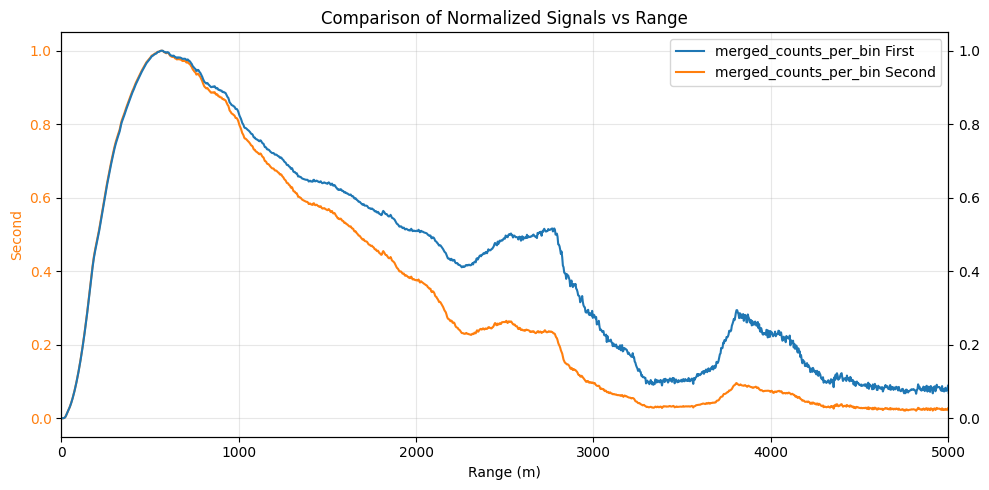

In [75]:
fig, ax1 = plt.subplots(figsize=(10,5))

# ---- Left axis (Prototype) ----
color1 = "tab:orange"

ax1.plot(
    NRB_processed["range_m"],
    NRB_processed["range2_norm"],
    label="merged_counts_per_bin Second",
    color=color1,
)

ax1.set_xlabel("Range (m)")
ax1.set_ylabel("Second", color=color1)
ax1.tick_params(axis="y", labelcolor=color1)
ax1.set_xlim(0,5000)


# ---- Right axis (MiniMPL) ----
ax2 = ax1.twinx()

color2 = "tab:blue"

ax2.plot(
    df_Sig["range_m"],
    df_Sig["range2_norm"],
    label="merged_counts_per_bin First",
    color=color2,
)

# ax2.set_ylabel("MiniMPL Normalized NRB", color=color2)
# ax2.tick_params(axis="y", labelcolor=color2)
# ax2.set_ylim(0,1)
# ---- Title / grid ----
ax1.set_title("Comparison of Normalized Signals vs Range")
ax1.grid(True, alpha=0.3)

# ---- Combined legend (MiniMPL first) ----
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(lines2 + lines1, labels2 + labels1)

plt.tight_layout()
plt.show()